# 08 — Reentrenamiento final y evaluacion en holdout

### Objetivo
Tomar los mejores hiperparametros de `07_optuna_tuning.ipynb`, reentrenar XGBoost y LightGBM en todo `dev`, y evaluar con forecast **recursivo** en el holdout de 12 semanas — igual que `05_validacion_ts.ipynb`, para que la comparacion sea directa.

Al final se regrava `predicciones_holdout.csv` con el mismo formato que espera `06_heatmap_ranking.ipynb`, para poder rehacer las visualizaciones con el modelo tuneado sin tocar el notebook 06.

### Nota
Si en 07 usaste `DROP_TREND_FEATURES=True` y/o `FILLNA_VALUE=None`, este notebook usa la MISMA configuracion leida de `mejores_hiperparametros.json` (seccion `config`) para que el set de features y el manejo de NaN sean consistentes entre tuning y evaluacion final.


In [19]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

sys.path.append(str(Path.cwd()))
from forecast_utils import forecast_recursive_vectorized, rmse, mae, poisson_deviance, mcfadden_r2

DATA_DIR = Path("/Users/guillermo/Downloads/TA_IA_Aplicada/Data")
OPTUNA_DIR = DATA_DIR.parent / "Modelado" / "optuna"
SEMANA_HOLDOUT_INICIO = 63



In [20]:
# Cargar mejores hiperparametros y config usada en el tuning
with open(OPTUNA_DIR / "mejores_hiperparametros.json") as f:
    resultado_optuna = json.load(f)

params_xgb = resultado_optuna["xgboost"]
params_lgbm = resultado_optuna["lightgbm"]
config = resultado_optuna["config"]
feature_cols = config["feature_cols"]
fillna_value = config["fillna_value"]

print(f"Features usadas: {len(feature_cols)}")
print(f"fillna_value: {fillna_value}")
print(f"Params XGBoost: {params_xgb}")
print(f"Params LightGBM: {params_lgbm}")



Features usadas: 24
fillna_value: None
Params XGBoost: {'n_estimators': 604, 'max_depth': 3, 'learning_rate': 0.018169391195341247, 'min_child_weight': 5, 'subsample': 0.9155444860229962, 'colsample_bytree': 0.8256742685398336, 'reg_alpha': 0.002616105131918576, 'reg_lambda': 2.4854089905414054}
Params LightGBM: {'n_estimators': 539, 'num_leaves': 119, 'max_depth': 3, 'learning_rate': 0.017987863473362915, 'min_child_samples': 7, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.7554709158757927, 'reg_alpha': 0.007865589790890783, 'reg_lambda': 0.7614139119869378}


In [21]:
# Carga y split dev / holdout (identico a 03/04/05/07)
df = pd.read_csv(DATA_DIR / "df_features.csv")
df_dev = df[df["semana_global"] < SEMANA_HOLDOUT_INICIO].copy()
df_holdout = df[df["semana_global"] >= SEMANA_HOLDOUT_INICIO].copy()

turno_cols = [c for c in df_dev.columns if c.startswith("turno_")]
df_dev["turno_hecho"] = df_dev[turno_cols].idxmax(axis=1).str.replace("turno_", "")
df_holdout["turno_hecho"] = df_holdout[turno_cols].idxmax(axis=1).str.replace("turno_", "")

print(f"Dev: {df_dev.shape[0]} | Holdout: {df_holdout.shape[0]}")



Dev: 10664 | Holdout: 2064


In [22]:
# Reentrenar en TODO dev con los mejores hiperparametros
X_dev = df_dev[feature_cols].astype(float).values
y_dev = df_dev["count_robos"].values

modelo_xgb_tuned = XGBRegressor(
    objective="count:poisson", random_state=42, n_jobs=-1,
    tree_method="hist", verbosity=0, **params_xgb,
)
modelo_xgb_tuned.fit(X_dev, y_dev)

modelo_lgbm_tuned = LGBMRegressor(
    objective="poisson", random_state=42, n_jobs=-1, verbosity=-1, **params_lgbm,
)
modelo_lgbm_tuned.fit(X_dev, y_dev)

print("Modelos tuneados reentrenados en dev completo")



Modelos tuneados reentrenados en dev completo


In [23]:
# Prediccion recursiva en el holdout (12 semanas)
y_true_xgb, y_pred_xgb_tuned, rmse_xgb_sem = forecast_recursive_vectorized(
    modelo_xgb_tuned, df_holdout, df_dev, feature_cols, fillna_value=fillna_value
)
y_true_lgbm, y_pred_lgbm_tuned, rmse_lgbm_sem = forecast_recursive_vectorized(
    modelo_lgbm_tuned, df_holdout, df_dev, feature_cols, fillna_value=fillna_value
)

resultados_tuned = []
for nombre, y_true, y_pred in [
    ("XGBoost (tuned)", y_true_xgb, y_pred_xgb_tuned),
    ("LightGBM (tuned)", y_true_lgbm, y_pred_lgbm_tuned),
]:
    r, m, d = rmse(y_true, y_pred), mae(y_true, y_pred), poisson_deviance(y_true, y_pred)
    r2 = mcfadden_r2(y_true, y_pred)
    print(f"  {nombre:20s} | RMSE={r:6.3f} | MAE={m:6.3f} | PoissonDev={d:10.1f} | R2={r2:6.3f}")
    resultados_tuned.append({"modelo": nombre, "rmse": r, "mae": m, "poisson_dev": d, "mcfadden_r2": r2})



  XGBoost (tuned)      | RMSE= 6.110 | MAE= 3.941 | PoissonDev=    5098.7 | R2= 0.789
  LightGBM (tuned)     | RMSE= 6.092 | MAE= 3.967 | PoissonDev=    5123.3 | R2= 0.788


/opt/anaconda3/envs/deep_learn_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/deep_learn_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/deep_learn_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/deep_learn_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/deep_learn_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, 

In [24]:
# Comparar contra los resultados previos (notebook 05), si el archivo existe
path_previo = DATA_DIR / "resultados_validacion_recursiva.csv"
if path_previo.exists():
    df_previo = pd.read_csv(path_previo)
    print("\n=== Resultados previos (05_validacion_ts, sin tuning) ===")
    print(df_previo.to_string(index=False))
    print("\n=== Resultados con tuning (este notebook) ===")
    print(pd.DataFrame(resultados_tuned)[["modelo", "rmse"]].to_string(index=False))
else:
    print(f"No se encontro {path_previo}; corre 05_validacion_ts.ipynb primero para comparar.")




=== Resultados previos (05_validacion_ts, sin tuning) ===
  modelo   esquema     rmse
LightGBM recursivo 6.511450
 XGBoost recursivo 6.482388

=== Resultados con tuning (este notebook) ===
          modelo     rmse
 XGBoost (tuned) 6.109887
LightGBM (tuned) 6.091565


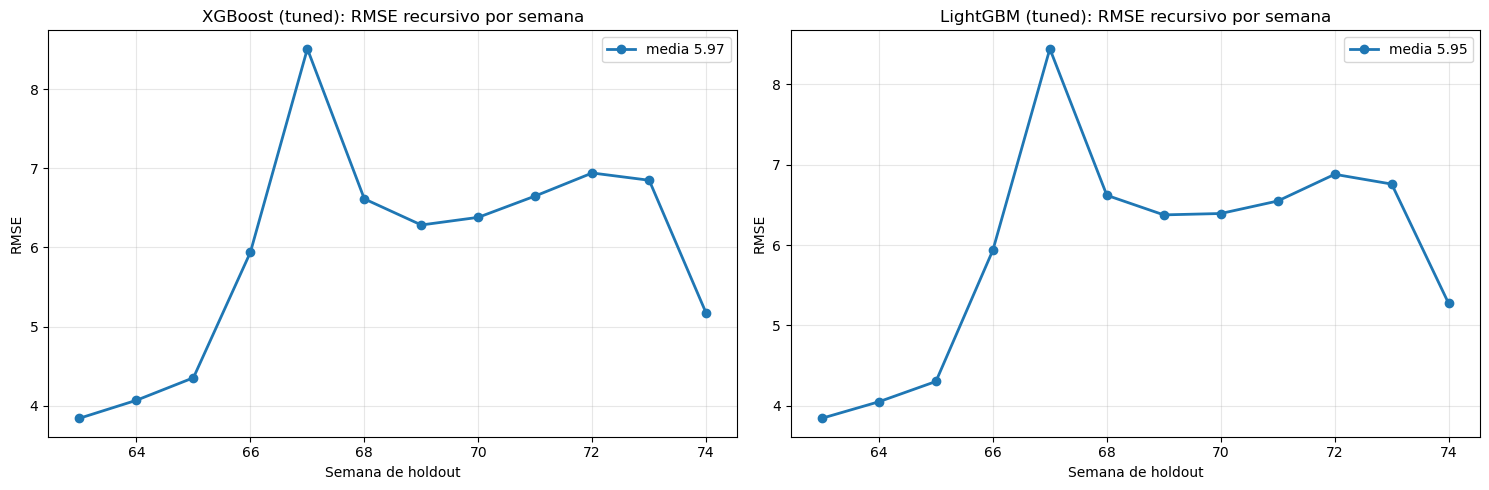

In [25]:
# Visualizacion: RMSE recursivo por semana, tuned vs config anterior guardada en 07
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, rmse_sem, nombre in zip(axes, [rmse_xgb_sem, rmse_lgbm_sem], ["XGBoost (tuned)", "LightGBM (tuned)"]):
    semanas = [r["semana"] for r in rmse_sem]
    valores = [r["rmse"] for r in rmse_sem]
    ax.plot(semanas, valores, marker="o", lw=2, label=f"media {np.mean(valores):.2f}")
    ax.set_xlabel("Semana de holdout")
    ax.set_ylabel("RMSE")
    ax.set_title(f"{nombre}: RMSE recursivo por semana")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OPTUNA_DIR / "validacion_recursiva_tuned.png", dpi=120, bbox_inches="tight")
plt.show()



In [26]:
# Guardar resultados, modelos y predicciones (mismo formato que espera 06_heatmap_ranking)
pd.DataFrame(resultados_tuned).to_csv(OPTUNA_DIR / "resultados_validacion_tuned.csv", index=False)

joblib.dump(modelo_xgb_tuned, OPTUNA_DIR / "modelo_xgb_tuned.joblib")
joblib.dump(modelo_lgbm_tuned, OPTUNA_DIR / "modelo_lgbm_tuned.joblib")

df_holdout_pred = df_holdout[["distrito_hecho", "turno_hecho", "año_semana",
                               "semana_global", "count_robos"]].copy()
df_holdout_pred["pred_xgboost"] = y_pred_xgb_tuned
df_holdout_pred["pred_lightgbm"] = y_pred_lgbm_tuned

print(f"Std real (holdout):        {np.std(y_true_lgbm):.2f}")
print(f"Std predicho (tuned):      {np.std(y_pred_lgbm_tuned):.2f}")
print(f"\nMejores params: {params_lgbm}")

# Guarda una copia versionada Y sobreescribe la que usa 06_heatmap_ranking.ipynb.
# Revisa el diff antes si quieres conservar las predicciones sin tuning.
df_holdout_pred.to_csv(OPTUNA_DIR / "predicciones_holdout_tuned.csv", index=False)
df_holdout_pred.to_csv(DATA_DIR / "predicciones_holdout.csv", index=False)

print(f"Guardado en {OPTUNA_DIR} y {DATA_DIR / 'predicciones_holdout.csv'}")
print("\nPuedes volver a correr 06_heatmap_ranking.ipynb sin modificarlo: "
      "va a leer las predicciones tuneadas automaticamente.")



Std real (holdout):        12.14
Std predicho (tuned):      9.62

Mejores params: {'n_estimators': 539, 'num_leaves': 119, 'max_depth': 3, 'learning_rate': 0.017987863473362915, 'min_child_samples': 7, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.7554709158757927, 'reg_alpha': 0.007865589790890783, 'reg_lambda': 0.7614139119869378}
Guardado en /Users/guillermo/Downloads/TA_IA_Aplicada/Modelado/optuna y /Users/guillermo/Downloads/TA_IA_Aplicada/Data/predicciones_holdout.csv

Puedes volver a correr 06_heatmap_ranking.ipynb sin modificarlo: va a leer las predicciones tuneadas automaticamente.


### Resumen
- Compara `rmse` de este notebook contra `resultados_validacion_recursiva.csv` (notebook 05) para confirmar si el tuning realmente mejoro el holdout, no solo el CV.
- Si el CV (notebook 07) tenia pocos folds (dev corto + burn-in de 52 semanas), trata el resultado de Optuna como una guia, no como verdad absoluta — el holdout de 12 semanas sigue siendo tu mejor evidencia real.
